# Regressionsbaum

## Ziel des Regressionsbaums

Der Regressionsbaum untersucht den Basispreis in USD.  
Er zeigt klar, welche Merkmale den Fahrzeugpreis besonders prägen.  
Dabei wird sichtbar, wie sich verschiedene Preisbereiche entwickeln.  
So wird die Preisstruktur des Modells nachvollziehbar dargestellt.

## Setup
### Imports, Pfade und Helper

In [2]:
# Imports
from pathlib import Path
from pathlib import PurePath
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score


# Pfade
ROOT = Path.cwd()
BASE_DIR = ROOT

INPUT_RAW = ROOT / "input" / "raw"
INPUT_PROCESSED = ROOT / "input" / "processed"

OUT = ROOT / "output"
FIG_DIR = OUT / "figures"          

FIG_TREE = FIG_DIR / "modeling" / "regressionsbaum"
FIG_TREE.mkdir(parents=True, exist_ok=True)

for p in [INPUT_RAW, INPUT_PROCESSED, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Datei wählen
DATA_FILE = INPUT_PROCESSED / "mercedes_sales_processed.csv"


# Helper
def _slugify(text: str) -> str:
    text = (text or "").strip()
    text = re.sub(r"[^\w\s-]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text if text else "Plot"

def _next_plot_number(fig_dir: Path) -> int:
    pattern = re.compile(r"^(\d{2,})_.*\.png$", re.IGNORECASE)
    nums = []
    for p in fig_dir.glob("*.png"):
        m = pattern.match(p.name)
        if m:
            nums.append(int(m.group(1)))
    return (max(nums) + 1) if nums else 1


plot_counter_tree = _next_plot_number(FIG_TREE)

def save_current_plot_tree(dpi: int = 300):
    global plot_counter_tree

    fig = plt.gcf()
    if fig is None or len(fig.axes) == 0:
        print("Kein Plot zum Speichern")
        return

    title = plt.gca().get_title() or "plot"
    slug = _slugify(title)

    # Prüfen, ob Datei mit diesem Titel existiert
    existing = list(FIG_TREE.glob(f"* {slug}.png"))

    if existing:
        print(f"Übersprungen (Titel existiert bereits): {existing[0].name}")
        return

    # Wenn nicht vorhanden → speichern
    filename = f"{plot_counter_tree:02d} {slug}.png"
    filepath = FIG_TREE / filename

    fig.tight_layout()
    fig.savefig(filepath, dpi=dpi, bbox_inches="tight")

    print(f"Gespeichert: {filepath.name}")

    plot_counter_tree += 1

## Datenbasis

In [3]:
# Datei prüfen
if not DATA_FILE.exists():
    raise FileNotFoundError(f"Datei nicht gefunden: {DATA_FILE}")

# Daten laden
df = pd.read_csv(DATA_FILE)

print("Shape:", df.shape)
display(df.head())

Shape: (12129513, 8)


,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Turbo
0,A-Class,2020,Global,Yellow,Diesel,41265,252,Yes
1,A-Class,2020,Global,Black,Petrol,51023,249,No
2,A-Class,2020,Global,Grey,Petrol,72819,341,Yes
3,A-Class,2020,Global,Black,Petrol,62480,385,Yes
4,A-Class,2020,Global,White,Petrol,35189,337,Yes


- Verwendung der im EDA erstellten `processed.csv`  
- 1.212.951 Beobachtungen und 8 Variablen  
- Mischung aus numerischen und kategorialen Merkmalen  
- Geeignete Datenbasis für die Modellierung  

## Zielvariable und Features

In [4]:
# Zielvariabel
TARGET = "Base Price (USD)"

# Numerische Features
num_features = ["Year", "Horsepower"]

# Kategoriale Features
cat_features = ["Region", "Fuel Type", "Turbo", "Model", "Color"]

X = df[num_features + cat_features].copy()
y = df[TARGET].copy()

print("Target:", TARGET)
print("Numerische Features:", num_features)
print("Kategoriale Features:", cat_features)

Target: Base Price (USD)
Numerische Features: ['Year', 'Horsepower']
Kategoriale Features: ['Region', 'Fuel Type', 'Turbo', 'Model', 'Color']


In [5]:
# kategoriale Variablen umkodieren für Regressionsbaum
X_encoded = pd.get_dummies(X, columns=cat_features, drop_first=True)

print("Shape nach Encoding:", X_encoded.shape)
display(X_encoded.head())

Shape nach Encoding: (12129513, 31)


,Year,Horsepower,Fuel Type_Electric,Fuel Type_Hybrid,Fuel Type_Petrol,Turbo_Yes,Model_AMG A 45,Model_AMG C 63,Model_AMG E 63,Model_AMG GT,...,Model_S-Class,Color_Blue,Color_Brown,Color_Green,Color_Grey,Color_Orange,Color_Red,Color_Silver,Color_White,Color_Yellow
0,2020,252,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2020,249,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2020,341,False,False,True,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,2020,385,False,False,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2020,337,False,False,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


- Zielvariable ist der Basispreis in USD
- Numerische und kategoriale Einflussfaktoren wurden definiert
- Kategoriale Variablen wurden mittels One-Hot-Encoding transformiert
- Nach Encoding stehen 31 Prädiktoren zur Verfügung
- Die Daten sind vollständig modellbereit

## Modellierung (Train/Test und Training)

In [6]:
# 1 Mio. Stichproben mit zufällige Ziehungen
df_model = df.sample(n=1_000_000, random_state=42)
X = df_model[num_features + cat_features].copy()
y = df_model[TARGET].copy()
X_encoded = pd.get_dummies(X, columns=cat_features, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42
)
# 80/20 Split
tree = DecisionTreeRegressor(
    max_depth=6,
    min_samples_split=2000,
    min_samples_leaf=1000,
    random_state=42
)

tree.fit(X_train, y_train)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (800000, 31) Test: (200000, 31)


- Aufgrund der sehr großen Fallzahl (12.129.513 Beobachtungen) wurde eine zufällige Stichprobe von 1.000.000 Fällen gezogen
- Die Ziehung erfolgte reproduzierbar mit festem Random State
- Die Stichprobe ist ausreichend groß, um die zugrunde liegende Datenstruktur stabil abzubilden
- Ziel ist die Reduktion der Rechenzeit ohne methodische Verzerrung

## Evaluation

### Cross-Validation

In [7]:
cv_scores = cross_val_score(
    tree,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("R² je Fold:", cv_scores)
print("Durchschnittliches R²:", round(cv_scores.mean() * 100, 1), "%")
print("Standardabweichung:", round(cv_scores.std() * 100, 2), "%")

R² je Fold: [0.63855253 0.63725232 0.63989281 0.63651124 0.63877279]
Durchschnittliches R²: 63.8 %
Standardabweichung: 0.12 %


- Durchschnittliche R² beträgt 63,8 %
- Standardabweichung liegt bei lediglich 0,12 %
- Ist über verschiedene Datenaufteilungen hinweg sehr stabil
- Keine Hinweise auf Überanpassung vor

In [8]:
# Gelernte Struktur auf Testdaten anwenden
y_pred = tree.predict(X_test)

# Kennzahlen berechnen
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

# Runden
r2_rounded = round(r2*100, 1)
rmse_rounded = round(rmse, -2)
mae_rounded = round(mae, -2)

print(f"R²: {r2_rounded} %")
print(f"RMSE: {rmse_rounded:,.0f} USD")
print(f"MAE: {mae_rounded:,.0f} USD")

R²: 63.8 %
RMSE: 40,500 USD
MAE: 29,700 USD


- Das Modell erklärt 63,8 % der Varianz des Basispreises
- Der RMSE beträgt 40.500 USD und gewichtet größere Abweichungen stärker
- Der MAE beträgt 29.700 USD und beschreibt die durchschnittliche Prognoseabweichung
- Der Regressionsbaum zeigt eine solide, jedoch nicht vollständige Erklärungskraft

In [9]:
# Wichtige Merkmale ermitteln
einflussfaktoren = pd.DataFrame({
    "Merkmal": X_encoded.columns,
    "Wichtigkeit": tree.feature_importances_
}).sort_values("Wichtigkeit", ascending=False)

einflussfaktoren.head(10)

,Merkmal,Wichtigkeit
20,Model_GLS,0.331797
21,Model_S-Class,0.272206
15,Model_G-Class,0.168035
6,Model_AMG A 45,0.082834
1,Horsepower,0.069685
7,Model_AMG C 63,0.068303
0,Year,0.007108
3,Fuel Type_Hybrid,0.000016
4,Fuel Type_Petrol,0.000011
29,Color_White,0.000005


Gespeichert: 01 Relative Merkmale - Top 10.png


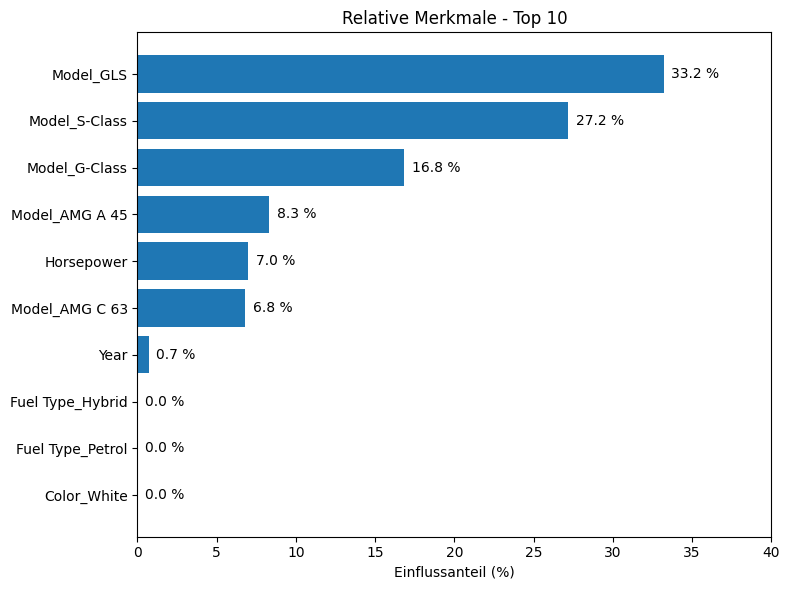

In [10]:
top15 = einflussfaktoren.head(10).copy()
top15["Einfluss (%)"] = (top15["Wichtigkeit"] * 100).round(1)

plt.figure(figsize=(8,6))
bars = plt.barh(top15["Merkmal"], top15["Einfluss (%)"])

plt.gca().invert_yaxis()
plt.title("Relative Merkmale - Top 10")
plt.xlabel("Einflussanteil (%)")
plt.xlim(0, 40) # bis 40% für bessere Darstellung

save_current_plot_tree()

# Beschriftung Balken 
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f} %",
        va="center"
    )
    
plt.tight_layout()
plt.show()

- Modellzugehörigkeit dominiert Preisbestimmung (GLS, S-Klasse, G-Klasse)
- Motorleistung -> moderaten Einfluss
- Baujahr -> geringe Rolle
- Kraftstoffart / Farbe tragen kaum zur Preisvariation bei
- Basispreis primär durch Fahrzeugklasse bestimmt

Gespeichert: 02 Regressionsbaum Ausschnitt bis Tiefe 3.png


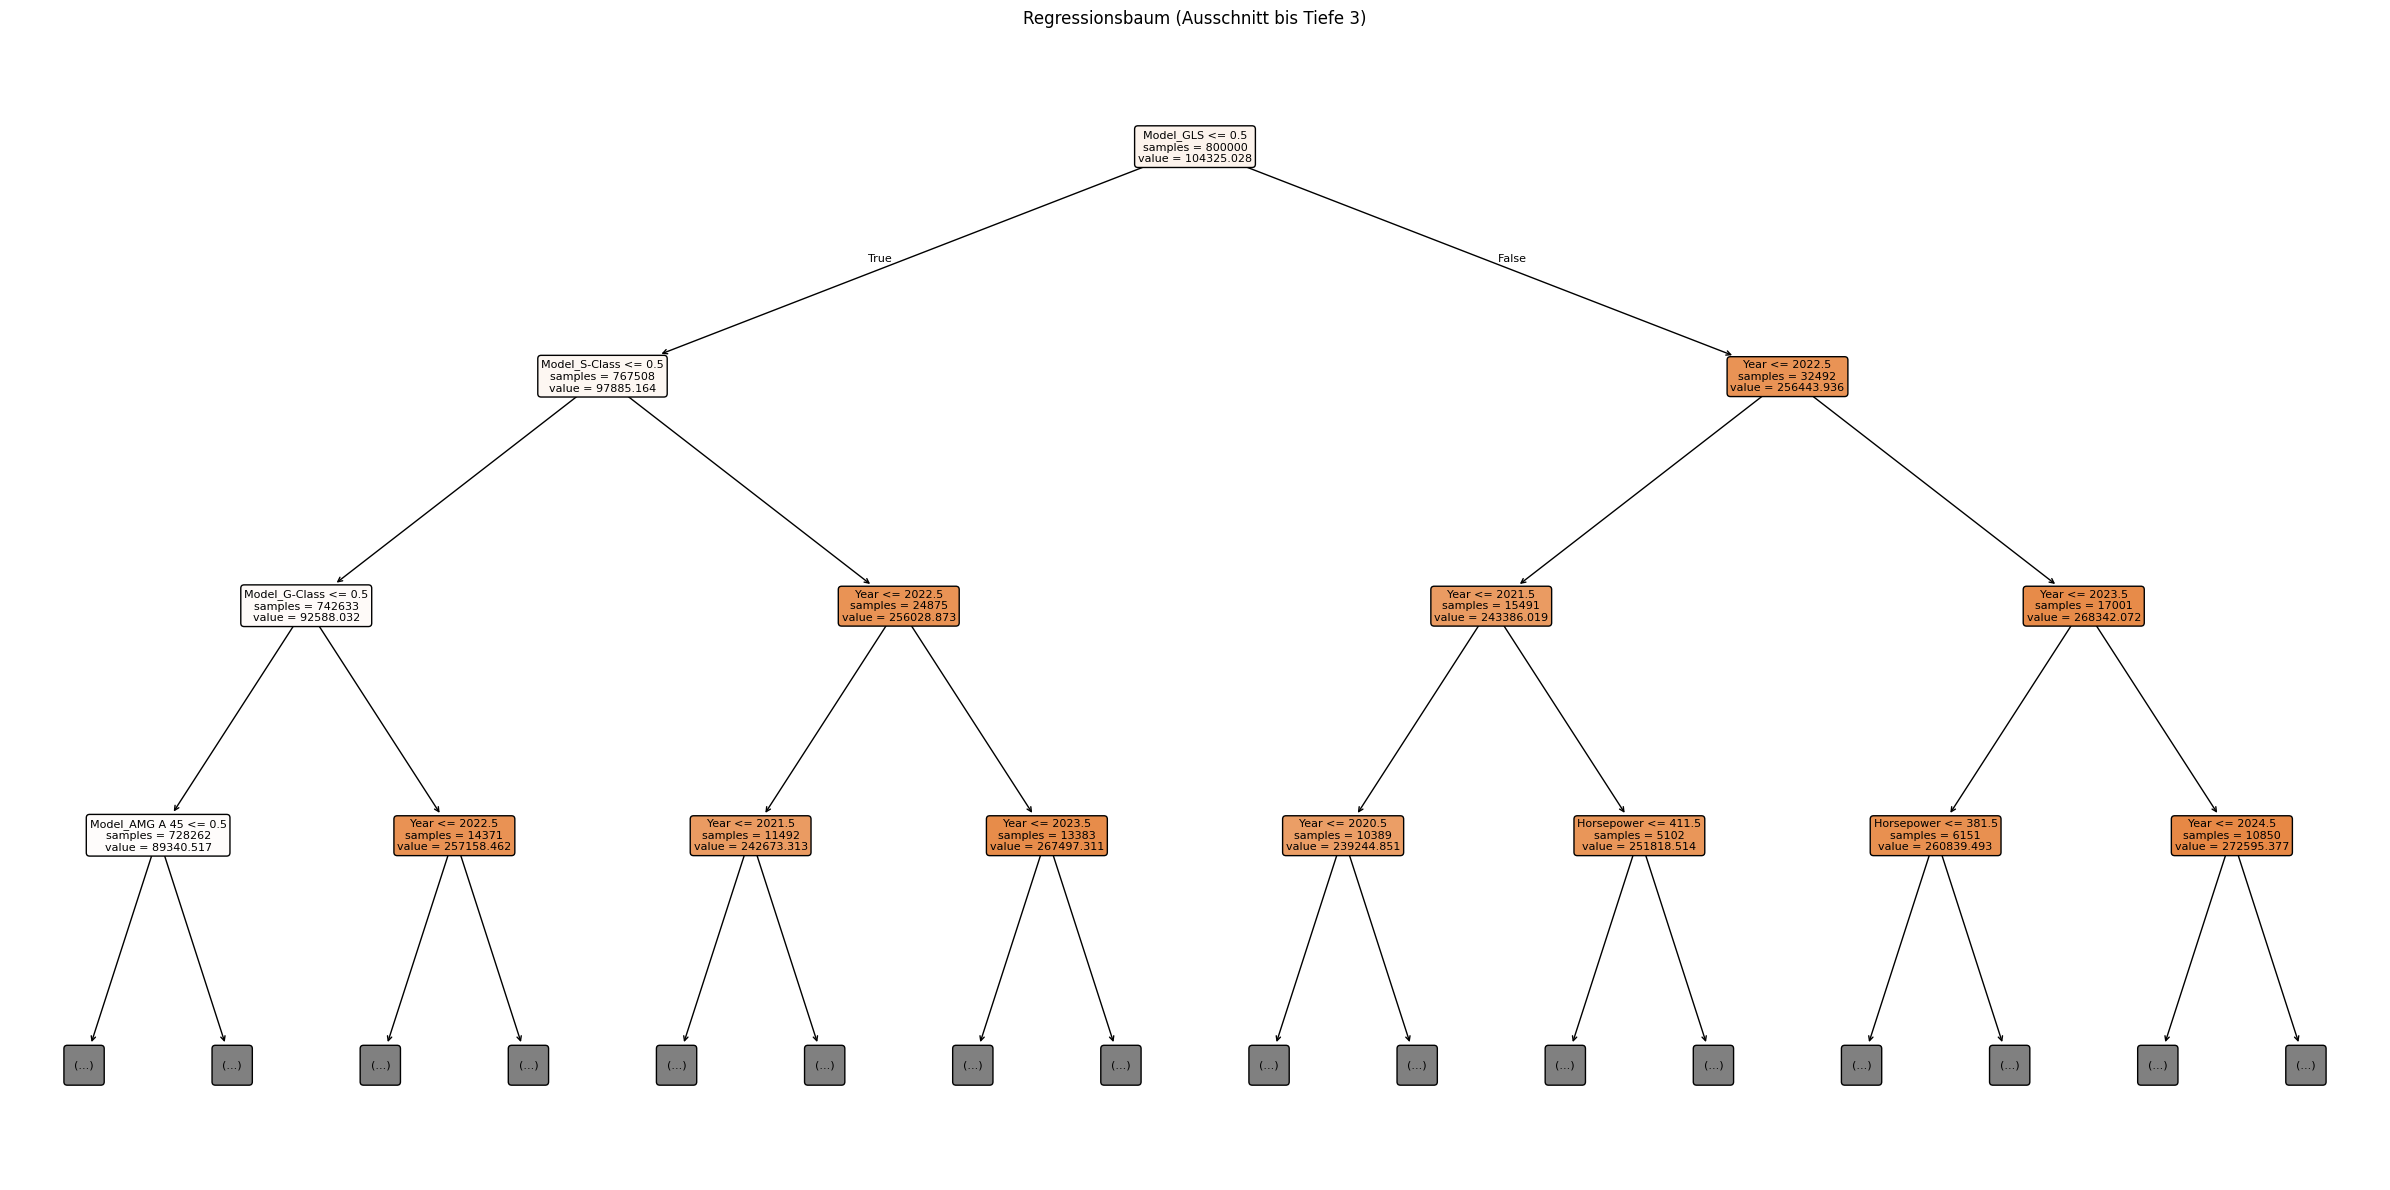

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 12))
plot_tree(
    tree,
    feature_names=X_encoded.columns,
    filled=True,
    rounded=True,
    max_depth=3,          # -> 3 Ebene zur besseren Übersicht
    impurity=False,
    fontsize=8
)
plt.title("Regressionsbaum (Ausschnitt bis Tiefe 3)")

save_current_plot_tree()

plt.tight_layout()
plt.show()

- Erster Split erfolgt nach dem Modell (GLS) → stärkster Preiseinfluss
- Weitere Splits erfolgen nach S-Klasse und G-Klasse
- In späteren Ebenen gewinnt das Baujahr an Bedeutung
- Motorleistung beeinflusst den Preis erst auf tieferen Ebenen
- Die Preisstruktur wird primär durch die Fahrzeugklasse bestimmt

Gespeichert: 03 Prognose vs Realität Stichprobe 10000.png


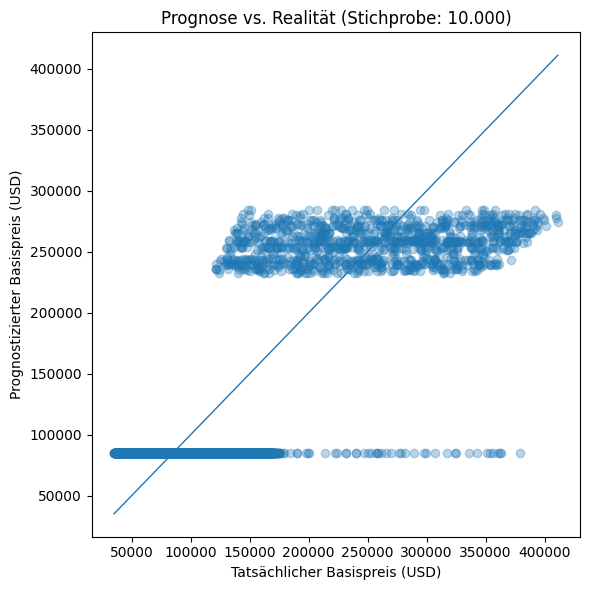

In [12]:
idx = np.random.RandomState(42).choice(len(y_test), size=10000, replace=False)

plt.figure(figsize=(6,6))
plt.scatter(y_test.iloc[idx], y_pred[idx], alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=1
)

plt.title("Prognose vs. Realität (Stichprobe: 10.000)")
plt.xlabel("Tatsächlicher Basispreis (USD)")
plt.ylabel("Prognostizierter Basispreis (USD)")
plt.tight_layout()
save_current_plot_tree()
plt.show()

- Punkte nahe der Diagonalen zeigen gute Vorhersagen
- Der Regressionsbaum segmentiert in diskrete Preiscluster
- Niedrige Preise werden stabil prognostiziert
- Bei hohen Preisen steigt die Streuung
- Hochpreisige Fahrzeuge werden tendenziell unterschätzt

# Gesamtwertung

- Modellklasse ist der wichtigste Preisfaktor
- Motorleistung wirkt als sekundärer technischer Treiber
- Regressionsbaum erklärt rund 64 % der Preisvarianz
- Preisstruktur folgt klar segmentierten Fahrzeugklassen